In [1]:
import os 
from torchvision import datasets, transforms 
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time 
import torchvision.models as models 
from matplotlib import pyplot as plt 
import optuna

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## LOAD DATA 

In [6]:
# Resizing the image for CNN 
image_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness = 0.2, contrast = 0.2) ,
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406], std = [0.229, 0.224,  0.225])
])

In [8]:
dataset_path = "./dataset"
dataset = datasets.ImageFolder(root = dataset_path, transform = image_transforms )
len(dataset)

2300

In [10]:
dataset.classes

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [12]:
num_classes = len(dataset.classes)
num_classes

6

In [14]:
train_size = int(0.75*len(dataset))
val_size = len(dataset) - train_size 

train_size, val_size 

(1725, 575)

In [16]:
from torch.utils.data import random_split 

train_dataset, val_dataset =  random_split(dataset, [train_size, val_size])

In [18]:
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = 32, shuffle = True)

In [20]:
for images, labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [22]:
labels[0]

tensor(3)

In [24]:
images[0].shape

torch.Size([3, 224, 224])

In [26]:
images[0].permute(1, 2, 0).shape

torch.Size([224, 224, 3])

In [28]:
images[0].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


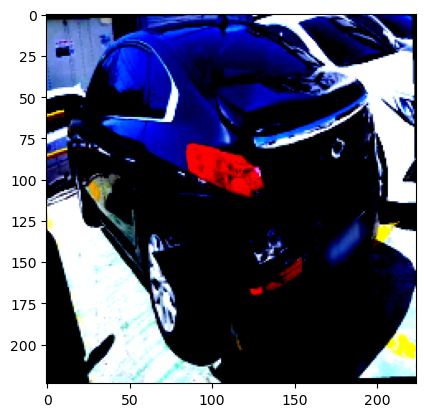

In [30]:
plt.imshow(images[0].permute(1,2,0))
plt.show()

## Transfer Learning with ResNet 

In [35]:
# Load the pre-trained ResNet model
class CarClassifierResNet(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.model = models.resnet50(weights='DEFAULT')
        # Freeze all layers except the final fully connected layer
        for param in self.model.parameters():
            param.requires_grad = False
            
        # Unfreeze layer4 and fc layers
        for param in self.model.layer4.parameters():
            param.requires_grad = True            
            
        # Replace the final fully connected layer
        self.model.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features, num_classes)
        )

    def forward(self, x):
        x = self.model(x)
        return x

In [37]:
# Define the objective function for Optuna
def objective(trial):
    # Suggest values for the hyperparameters
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.2, 0.7)
    
    # Load the model
    model = CarClassifierResNet(num_classes=num_classes, dropout_rate=dropout_rate).to(device)
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    
    # Training loop (using fewer epochs for faster hyperparameter tuning)
    epochs = 3
    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch_num, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        
        # Validation loop
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        
        # Report intermediate result to Optuna
        trial.report(accuracy, epoch)
        
        # Handle pruning (if applicable)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    end = time.time()
    print(f"Execution time: {end - start} seconds")
    
    return accuracy

In [ ]:
# Create the study and optimize
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

[I 2025-05-03 19:24:08,361] A new study created in memory with name: no-name-d4e8fd5b-634a-4e63-99e3-2902597472e2
[I 2025-05-03 19:42:52,865] Trial 0 finished with value: 73.73913043478261 and parameters: {'lr': 3.925931966354469e-05, 'dropout_rate': 0.3691756641223224}. Best is trial 0 with value: 73.73913043478261.


Execution time: 1124.0702319145203 seconds


[I 2025-05-03 20:11:38,933] Trial 1 finished with value: 78.43478260869566 and parameters: {'lr': 0.00014798217060119559, 'dropout_rate': 0.2412975657924482}. Best is trial 1 with value: 78.43478260869566.


Execution time: 1725.3777451515198 seconds


[I 2025-05-03 20:31:50,437] Trial 2 finished with value: 77.56521739130434 and parameters: {'lr': 0.0001745298483063853, 'dropout_rate': 0.34039670878994754}. Best is trial 1 with value: 78.43478260869566.


...

Execution time: 660.1245920658112 seconds


[I 2025-05-03 22:28:00,230] Trial 10 finished with value: 78.78260869565217 and parameters: {'lr': 0.0022278922573196335, 'dropout_rate': 0.6268538804078794}. Best is trial 4 with value: 80.34782608695652.


Execution time: 3415.3023693561554 seconds


[I 2025-05-03 22:38:23,011] Trial 11 finished with value: 77.56521739130434 and parameters: {'lr': 0.0008733145940989379, 'dropout_rate': 0.5412862907065686}. Best is trial 4 with value: 80.34782608695652.


Execution time: 622.4969937801361 seconds
